In [78]:
import pandas as pd
import numpy as np 

In [79]:
df = pd.read_excel("./CSVs/BIKE_FEBRUARY.xlsx")
df

,DAY,DATE,KM,PETROL_FILL,PETROL RATE,PETROL PUMP,PETROL AMOUNT,PETROL QUANTITY,BIKE_DRIVEN_DAY
0,SUNDAY,2026-02-01,1091.80,0,0.00,NaN,NaN,NaN,0.00
1,MONDAY,2026-02-02,1112.50,0,0.00,NaN,NaN,NaN,20.70
2,TUESDAY,2026-02-03,1139.70,1,94.50,BHARAT PETROLEUM,100.0,1.06,27.20
3,WEDNESDAY,2026-02-04,1157.55,0,0.00,NaN,NaN,NaN,17.85
4,THRUSDAY,2026-02-05,1175.40,0,0.00,NaN,NaN,NaN,17.85
5,FRIDAY,2026-02-06,1193.25,0,0.00,NaN,NaN,NaN,17.85
6,SATURDAY,2026-02-07,1211.10,0,0.00,NaN,NaN,NaN,17.85
7,SUNDAY,2026-02-08,1211.10,0,0.00,NaN,NaN,NaN,0.00
8,MONDAY,2026-02-09,1234.60,1,94.50,BHARAT PETROLEUM,200.0,2.12,23.50
9,TUESDAY,2026-02-10,1256.40,0,0.00,NaN,NaN,NaN,21.80


In [80]:
df.describe()

,DATE,KM,PETROL_FILL,PETROL RATE,PETROL AMOUNT,PETROL QUANTITY,BIKE_DRIVEN_DAY
count,28,28.000000,28.000000,28.000000,3.000000,3.000000,28.000000
mean,2026-02-14 12:00:00,1328.641786,0.107143,10.123571,300.000000,3.176667,16.794643
min,2026-02-01 00:00:00,1091.800000,0.000000,0.000000,100.000000,1.060000,0.000000
25%,2026-02-07 18:00:00,1211.100000,0.000000,0.000000,150.000000,1.590000,12.035000
50%,2026-02-14 12:00:00,1319.800000,0.000000,0.000000,200.000000,2.120000,17.850000
75%,2026-02-21 06:00:00,1445.320000,0.000000,0.000000,400.000000,4.235000,23.267500
max,2026-02-28 00:00:00,1562.050000,1.000000,94.500000,600.000000,6.350000,30.050000
std,NaN,140.103038,0.314970,29.760503,264.575131,2.798827,8.996089


In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

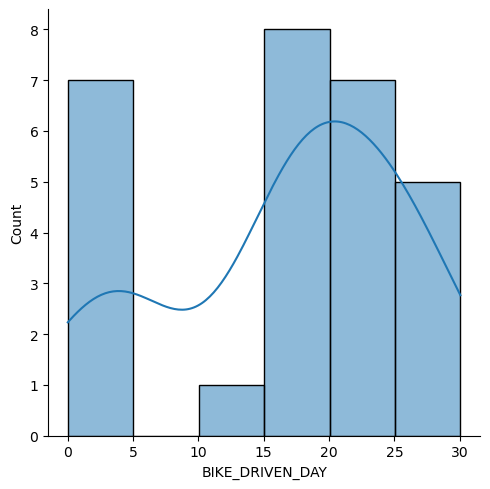

In [82]:
sns.displot(df.BIKE_DRIVEN_DAY,kde=True)

In [83]:
df['PETROL QUANTITY'].fillna(0,inplace=True) 
df['PETROL AMOUNT'].fillna(0,inplace=True) 
df['PETROL PUMP'].fillna(0,inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_9492\2898615885.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PETROL QUANTITY'].fillna(0,inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9492\2898615885.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [86]:
df.DATE = pd.to_datetime(df.DATE)

In [87]:
df["Date_d"]=df.DATE.dt.day

In [88]:
df

,DAY,DATE,KM,PETROL_FILL,PETROL RATE,PETROL PUMP,PETROL AMOUNT,PETROL QUANTITY,BIKE_DRIVEN_DAY,Date_d
0,SUNDAY,2026-02-01,1091.80,0,0.00,0,0.0,0.00,0.00,1
1,MONDAY,2026-02-02,1112.50,0,0.00,0,0.0,0.00,20.70,2
2,TUESDAY,2026-02-03,1139.70,1,94.50,BHARAT PETROLEUM,100.0,1.06,27.20,3
3,WEDNESDAY,2026-02-04,1157.55,0,0.00,0,0.0,0.00,17.85,4
4,THRUSDAY,2026-02-05,1175.40,0,0.00,0,0.0,0.00,17.85,5
5,FRIDAY,2026-02-06,1193.25,0,0.00,0,0.0,0.00,17.85,6
6,SATURDAY,2026-02-07,1211.10,0,0.00,0,0.0,0.00,17.85,7
7,SUNDAY,2026-02-08,1211.10,0,0.00,0,0.0,0.00,0.00,8
8,MONDAY,2026-02-09,1234.60,1,94.50,BHARAT PETROLEUM,200.0,2.12,23.50,9
9,TUESDAY,2026-02-10,1256.40,0,0.00,0,0.0,0.00,21.80,10


<Axes: xlabel='KM', ylabel='Date_d'>

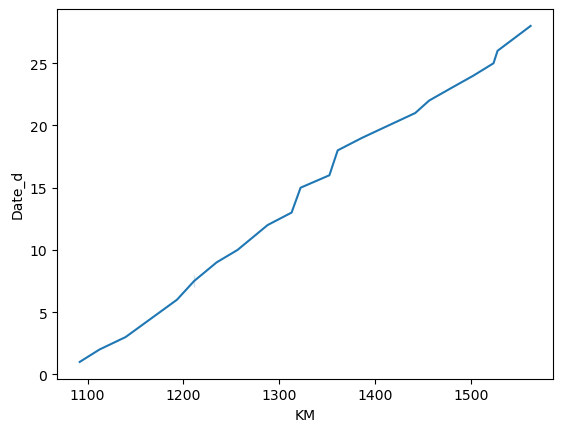

In [89]:
sns.lineplot(x=df.KM,y=df.Date_d)

In [96]:
print(f"Total Km Driven in Month : {df.KM.max()-df.KM.min()}")
print(f"Total Average of Month : {(df.KM.max()-df.KM.min())/df['PETROL QUANTITY'].sum()}")
print(f"Total Petrol amount : {df['PETROL QUANTITY'].sum() * df['PETROL RATE'].max()}")

Total Km Driven in Month : 470.25
Total Average of Month : 49.344176285414484
Total Petrol amount : 900.5849999999999


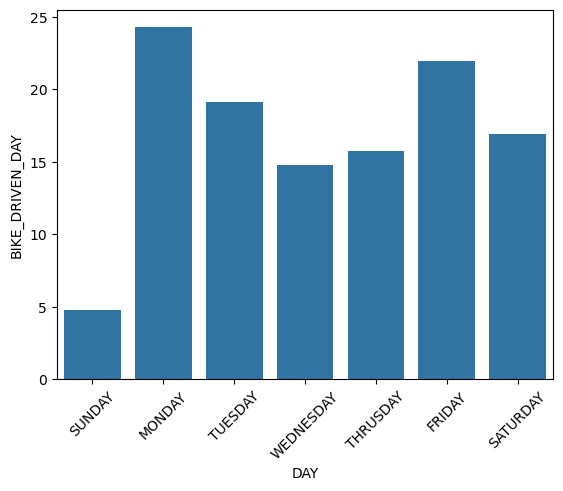

In [93]:
sns.barplot(x=df.DAY,y=df.BIKE_DRIVEN_DAY,errorbar=None)
plt.xticks(rotation=45)
plt.show()